<a href="https://colab.research.google.com/github/innsvi/python_for_ds_task/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/data/yulu_rental.csv')

In [3]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [4]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [5]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [6]:
# Розмір датасету
df.shape

(10886, 19)

In [7]:
print("Кількість рядків:", df.shape[0])
print("Кількість колонок:", df.shape[1])

Кількість рядків: 10886
Кількість колонок: 19


In [8]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [9]:
print("Початок періоду:", df.index.min())
print("Кінець періоду:", df.index.max())

Початок періоду: 2011-01-01 00:00:00
Кінець періоду: 2012-12-19 23:00:00


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [10]:
daily_count = df['count'].resample('D').sum()
daily_count.head()

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600


Text(0, 0.5, 'Кількість оренд')

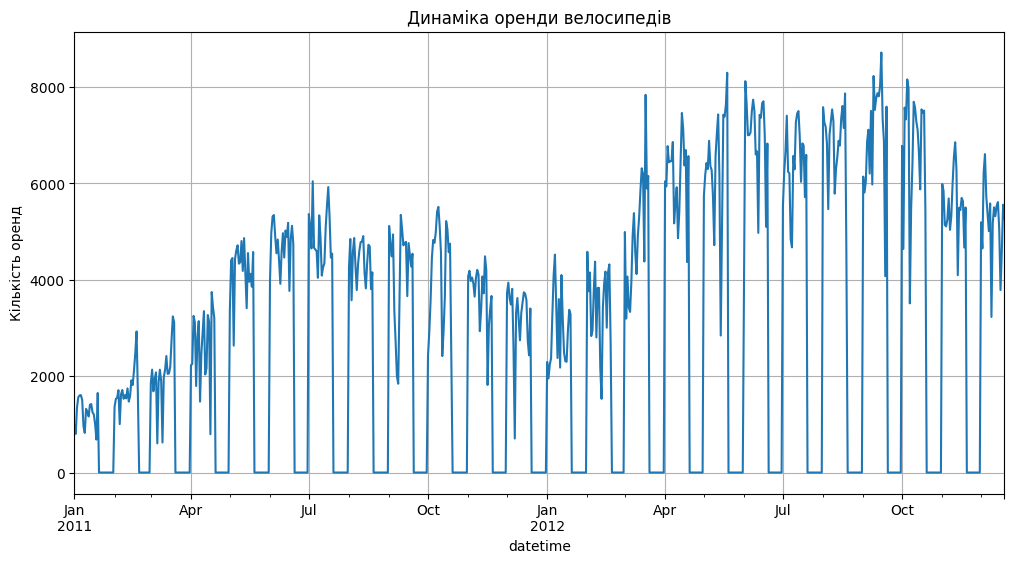

In [12]:
ax = daily_count.plot(figsize=(12, 6), title='Динаміка оренди велосипедів', grid=True)
ax.set_ylabel('Кількість оренд')

In [13]:
print("Мінімум за день:", daily_count.min())
print("Максимум за день:", daily_count.max())

Мінімум за день: 0
Максимум за день: 8714


In [14]:
print("Дата мінімуму:", daily_count.idxmin())
print("Дата максимуму:", daily_count.idxmax())

Дата мінімуму: 2011-01-20 00:00:00
Дата максимуму: 2012-09-15 00:00:00


In [15]:
print("Середня денна кількість оренд:", daily_count.mean())

Середня денна кількість оренд: 2900.5229485396385


**1. Чому графік має “заломи” і як їх прибрати?**
Заломи виникають через різкі падіння значень до нуля або майже до нуля, що, ймовірно, пов’язано з пропущеними чи неповними даними за окремі дні. Їх можна зменшити, якщо прибрати такі дні з аналізу, заповнити пропуски або використати згладжування, наприклад ковзне середнє.

**2. Які загальні тенденції видно на графіку?**
На графіку видно загальне зростання кількості оренд з 2011 до 2012 року. Це може свідчити про зростання популярності сервісу оренди велосипедів.

**3. Чи помітні сезонні коливання?**
Так, сезонність помітна: у тепліші періоди оренда вища, а в холодніші нижча. Отже, погодні та сезонні умови суттєво впливають на попит.

**4. Чи є аномально високі або низькі значення і чому?**
Так, є як дуже низькі, так і дуже високі значення. Низькі можуть бути пов’язані з пропущеними даними або поганою погодою, а високі  зі сприятливими умовами, вихідними чи зростанням популярності оренди.


**Графік показує зростання оренди велосипедів у часі, наявність сезонних коливань і окремих аномалій. Загалом попит залежить як від часу року, так і від якості зібраних даних**.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

<Axes: title={'center': 'Середня кількість оренд велосипедів за кварталами'}, xlabel='Квартал', ylabel='Середня кількість оренд'>

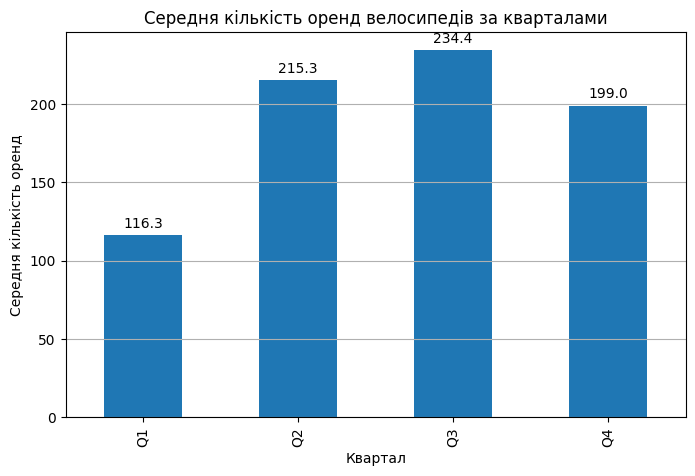

In [18]:
# Середня кількість оренд за кварталами
season_avg = df.groupby('season')['count'].mean()

# Замінимо числові значення назвами кварталів
season_labels = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

season_avg.index = season_avg.index.map(season_labels)

# Побудова стовпчастої діаграми
ax = season_avg.plot(kind='bar', figsize=(8, 5), title='Середня кількість оренд велосипедів за кварталами')

ax.set_xlabel('Квартал')
ax.set_ylabel('Середня кількість оренд')
ax.grid(axis='y')

# Підписи над стовпцями
for i, value in enumerate(season_avg):
    ax.text(i, value + 5, f'{value:.1f}', ha='center')

ax

**1. В який квартал найбільша середня кількість оренди велосипедів**?
Найбільша середня кількість оренд спостерігається у Q3 -  234.4. Найменше значення має Q1  приблизно 116.3.

**2. Як можна пояснити таку сезонну закономірність**?
У Q3 погода зазвичай тепліша та комфортніша, тому люди частіше користуються велосипедами. У Q1 оренда нижча, ймовірно, через холодніший період і менш сприятливі погодні умови.

**3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами**?
Обчислимо відношення: 234.4 / 116.3 = 2.02. Отже, в найпопулярнішому кварталі оренда приблизно у 2 рази більша, ніж у найменш популярному.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


<Axes: title={'center': 'Середня кількість оренди велосипедів за місяцями'}, xlabel='Місяць', ylabel='Середня кількість оренд'>

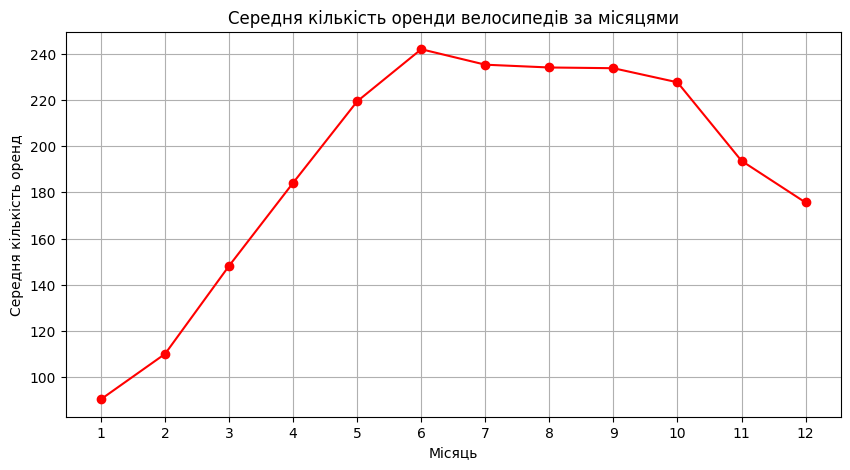

In [19]:
# Середня кількість оренд по місяцях
monthly_avg = df.groupby('month')['count'].mean()

# Побудова графіка
ax = monthly_avg.plot(
    kind='line',
    figsize=(10, 5),
    marker='o',
    color='red',
    grid=True,
    title='Середня кількість оренди велосипедів за місяцями'
)

ax.set_xlabel('Місяць')
ax.set_ylabel('Середня кількість оренд')
ax.set_xticks(range(1, 13))

ax

**1. В які місяці спостерігається пік та спад оренди**?
Пік оренди спостерігається у червні (6 місяць), а найменше значення  у січні (1 місяць). Також високі значення тримаються влітку та на початку осені.

**2. Чи збігається ця закономірність з результатами з попереднього завдання**?
Так, ця закономірність збігається з попереднім завданням: найвищі значення припадають на тепліші квартали, а найнижчі  на холодніші. Отже, місячний аналіз підтверджує сезонність, яку ми вже бачили на графіку по кварталах.

**3. Як може вплинути клімат на оренду велосипедів протягом року**?
У теплі місяці люди частіше користуються велосипедами через комфортніші погодні умови. У холодні, дощові або менш сприятливі періоди кількість оренд зменшується.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

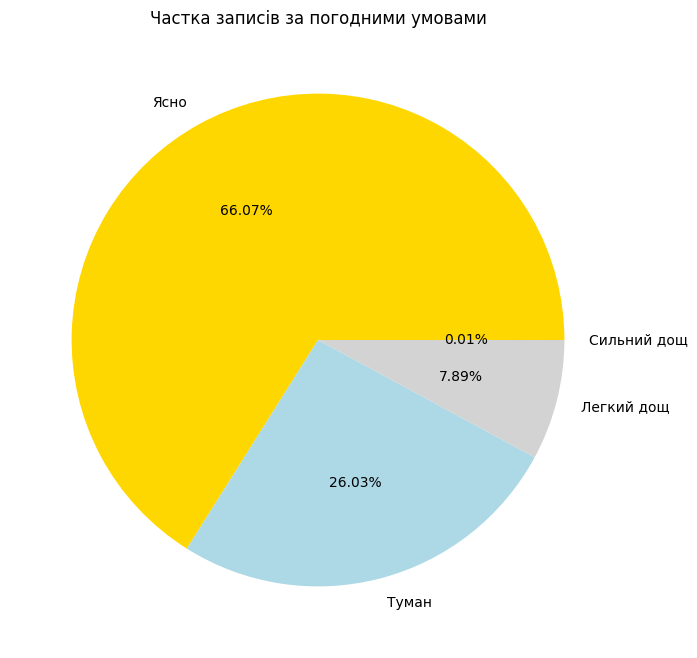

<Axes: title={'center': 'Розподіл записів за погодними умовами'}>

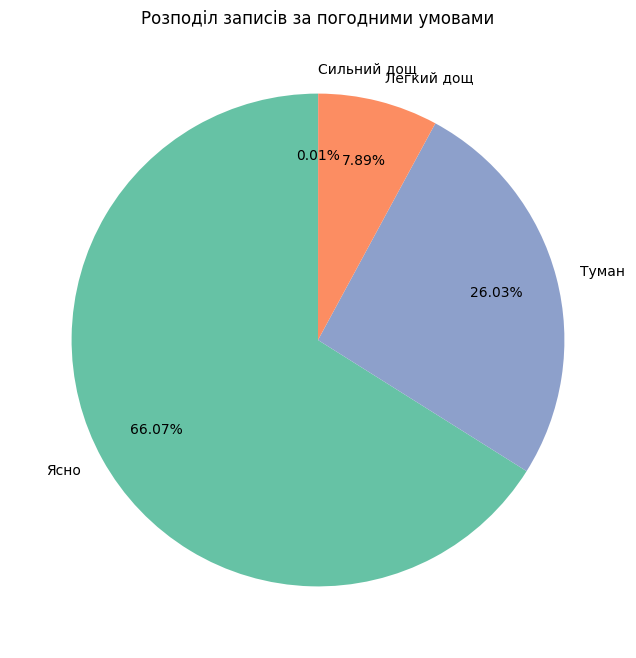

In [22]:
# Кількість записів за погодними умовами
weather_counts = df['weather'].value_counts().sort_index()

# Назви категорій погоди
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

labels = [weather_labels[i] for i in weather_counts.index]

# Власні кольори
colors = ['#66c2a5', '#8da0cb', '#fc8d62', '#e78ac3']

# Кругова діаграма
ax = weather_counts.plot(
    kind='pie',
    figsize=(8, 8),
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.75
)

ax.set_ylabel('')
ax.set_title('Розподіл записів за погодними умовами')

ax

**1. Яка погода переважає в датасеті**?
У датасеті переважає ясна погода  приблизно 66.07% усіх записів. На другому місці  туман із часткою близько 26.03%.

**2. Чи є дні із сильним дощем? Яка їх частка**?
Так, дні або записи із сильним дощем є, але їх дуже мало. Їхня частка становить приблизно 0.01%, тобто це майже поодинокі випадки.

**3. Як погодні умови впливають на попит на оренду велосипедів**?
Чим краща погода, тим вищим зазвичай є попит на оренду велосипедів. Під час дощу, туману або інших несприятливих умов кількість оренд, ймовірно, зменшується, бо користуватися велосипедом стає менш зручно і безпечно.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

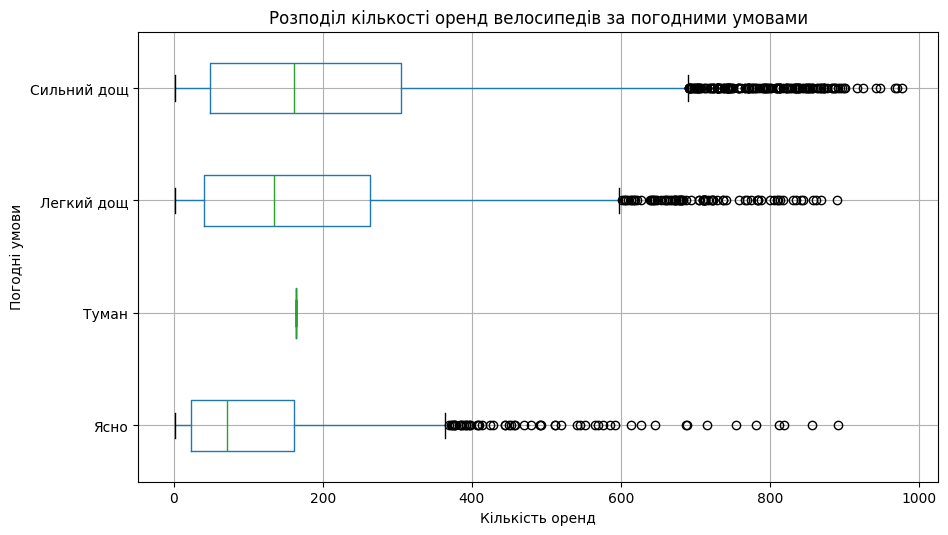

In [23]:
# Створимо копію датафрейму для зручності
df_box = df.copy()

# Замінимо числові коди погоди назвами
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df_box['weather_name'] = df_box['weather'].map(weather_labels)

# Порядок категорій
order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

# Box plot
ax = df_box.boxplot(
    column='count',
    by='weather_name',
    vert=False,
    figsize=(10, 6),
    grid=True
)

# Оформлення
plt.title('Розподіл кількості оренд велосипедів за погодними умовами')
plt.suptitle('')  # прибирає стандартний зайвий підзаголовок pandas
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.yticks(ticks=range(1, len(order) + 1), labels=order)

plt.show()

**1. При якій погоді найбільший розкид у кількості оренди**?
Найбільший розкид спостерігається при сильному дощі та легкому дощі, оскільки їхні коробки й “вуса” на графіку найбільш широкі. Це означає, що значення оренди в цих категоріях змінюються сильніше.

**2. Чи є викиди (outliers) в даних? При якій погоді**?
Так, викиди є, і вони помітні майже для всіх типів погоди. Особливо багато їх видно при ясній погоді, легкому дощі та сильному дощі.

**3. При якій погоді медіанне значення оренди найвище**?
Найвище медіанне значення оренди спостерігається при сильному дощі. Але цей результат варто трактувати обережно, бо таких записів у датасеті дуже мало.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

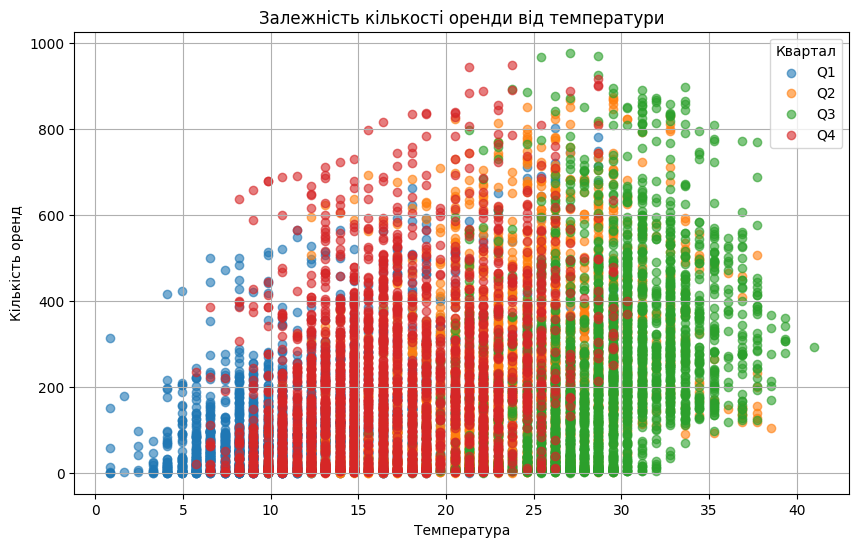

In [24]:
# Назви кварталів
season_labels = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

plt.figure(figsize=(10, 6))

for season, label in season_labels.items():
    subset = df[df['season'] == season]
    plt.scatter(
        subset['temp'],
        subset['count'],
        alpha=0.6,
        label=label
    )

plt.title('Залежність кількості оренди від температури')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.grid(True)
plt.legend(title='Квартал')

plt.show()

Так, зв’язок є, і він загалом позитивний: зі зростанням температури кількість оренд зазвичай теж зростає. Водночас цей зв’язок не є строго лінійним, бо при дуже високих температурах розкид значень більший і попит уже не зростає так однозначно.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

<Axes: title={'center': 'Середня кількість оренд за днями тижня'}, xlabel='День тижня', ylabel='Середня кількість оренд'>

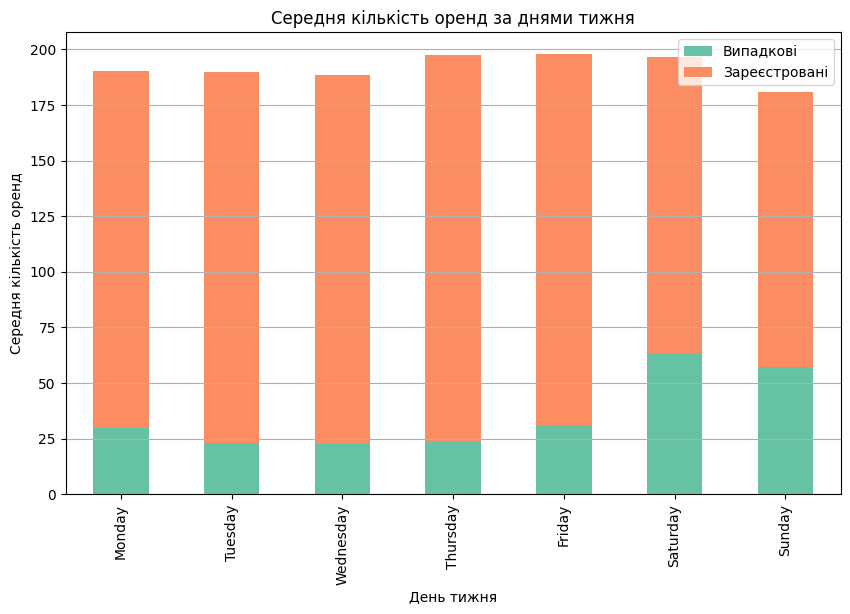

In [25]:
# Порядок днів тижня
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Середні значення casual і registered по днях тижня
weekday_avg = df.groupby('weekday')[['casual', 'registered']].mean().reindex(weekday_order)

# Побудова stacked bar chart
ax = weekday_avg.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#66c2a5', '#fc8d62']
)

ax.set_title('Середня кількість оренд за днями тижня')
ax.set_xlabel('День тижня')
ax.set_ylabel('Середня кількість оренд')
ax.legend(['Випадкові', 'Зареєстровані'])
ax.grid(axis='y')

ax

1. **В які дні тижня більше оренд від зареєстрованих користувачів**?
Найбільше оренд від зареєстрованих користувачів спостерігається у четвер, п’ятницю та суботу, а найменше у неділю. Загалом їхня кількість висока протягом усього тижня.

2. **Як можна пояснити таку різницю в поведінці користувачів протягом тижня**?
Зареєстровані користувачі, ймовірно, частіше орендують велосипеди для щоденних поїздок на роботу чи у справах, тому їхня активність стабільно висока в будні. Випадкові користувачі активніші у вихідні, коли люди частіше використовують велосипеди для відпочинку та прогулянок.